# Solar PV Power Forecasting using NASA POWER and PVLib

This Colab notebook builds a complete solar PV forecasting pipeline:

1. Load NASA POWER hourly weather/solar data.
2. Simulate PV power output using PVLib.
3. Build forecasting features.
4. Train baseline, Random Forest, XGBoost, LSTM, CNN, and CNN-LSTM models.
5. Generate model comparison, feature importance, SHAP explainability, and result plots.

**Important note:** the PV output in this project is **simulated using PVLib**, not measured from a physical solar plant. This must be clearly stated in the GitHub README and CV/project description.

## 1. Install dependencies

Run this cell first in Google Colab. TensorFlow is usually already available in Colab, but this installs the remaining packages.

In [ ]:
!pip -q install pvlib xgboost shap

## 2. Import libraries and create folders

In [ ]:
# ==========================================================
# 2. IMPORT LIBRARIES
# ==========================================================
import os
import random
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, LSTM, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import pvlib

from google.colab import files

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
DATA_DIR = Path("data")

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

## 3. Upload or locate NASA POWER CSV

Upload the NASA POWER CSV file when prompted. Rename is handled automatically inside the notebook.

Expected important columns:

- `YEAR`
- `MO`
- `DY`
- `HR`
- `ALLSKY_SFC_SW_DWN`
- `T2M`
- `WS10M`
- `QV2M`
- `PRECTOTCORR`

In [ ]:
# ==========================================================
# 3. UPLOAD NASA POWER CSV
# ==========================================================

DATA_PATH = DATA_DIR / "nasa_power_hourly.csv"

if not DATA_PATH.exists():
    print("Upload your NASA POWER CSV file.")
    uploaded = files.upload()
    uploaded_name = list(uploaded.keys())[0]
    Path(uploaded_name).rename(DATA_PATH)
    print(f"Saved file as: {DATA_PATH}")
else:
    print(f"Using existing file: {DATA_PATH}")

Using existing file: data/nasa_power_hourly.csv


## 4. Data loading and preprocessing

NASA POWER CSV files usually contain metadata lines before the real table. The function below detects the `-END HEADER-` line and skips metadata automatically.

In [ ]:
# ==========================================================
# 4. LOAD AND PREPROCESS NASA POWER DATA
# ==========================================================

REQUIRED_COLUMNS = ["YEAR", "MO", "DY", "HR", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]


def find_nasa_header_end(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if "-END HEADER-" in line:
                return i + 1
    return 0


def load_nasa_power_csv(file_path):
    skiprows = find_nasa_header_end(file_path)
    df = pd.read_csv(file_path, skiprows=skiprows)
    df.columns = df.columns.str.strip()
    return df


def preprocess_nasa_data(df):
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.copy()

    data["datetime"] = pd.to_datetime(
        dict(
            year=data["YEAR"].astype(int),
            month=data["MO"].astype(int),
            day=data["DY"].astype(int),
            hour=data["HR"].astype(int),
        ),
        utc=True,
        errors="coerce",
    )

    numeric_cols = [
        "ALLSKY_SFC_SW_DWN", "T2M", "WS10M",
        "QV2M", "PRECTOTCORR", "PS", "PSC", "WSC"
    ]

    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data.dropna(subset=["datetime", "ALLSKY_SFC_SW_DWN", "T2M", "WS10M"])
    data = data.sort_values("datetime").set_index("datetime")

    for col in data.select_dtypes(include="number").columns:
        data.loc[data[col] <= -900, col] = np.nan

    data = data.ffill().bfill()

    return data


nasa_raw = load_nasa_power_csv(DATA_PATH)
nasa_df = preprocess_nasa_data(nasa_raw)

print(nasa_df.shape)
nasa_df.head()

(12384, 12)


,YEAR,MO,DY,HR,T2M,QV2M,PRECTOTCORR,WS10M,ALLSKY_SFC_SW_DWN,PS,PSC,WSC
datetime,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,2025.0,1.0,1.0,0.0,15.68,7.87,0.0,4.59,0.0,103.05,103.10,3.46
2025-01-01 01:00:00+00:00,2025.0,1.0,1.0,1.0,15.66,7.89,0.0,4.42,0.0,103.05,103.10,3.32
2025-01-01 02:00:00+00:00,2025.0,1.0,1.0,2.0,15.65,7.91,0.0,4.22,0.0,103.03,103.08,3.17
2025-01-01 03:00:00+00:00,2025.0,1.0,1.0,3.0,15.57,7.92,0.0,4.07,0.0,103.02,103.07,3.05
2025-01-01 04:00:00+00:00,2025.0,1.0,1.0,4.0,15.42,7.94,0.0,4.20,0.0,103.01,103.07,3.15


## 5. Simulate PV power output using PVLib

This step converts NASA POWER irradiance and weather variables into simulated PV output.

Workflow:

`GHI → DNI/DHI decomposition → Plane-of-array irradiance → Cell temperature → PVWatts DC/AC power → pv_power_kw`

For an hourly interval, NASA `ALLSKY_SFC_SW_DWN` in Wh/m² can be approximately treated as average W/m² over that hour.

In [ ]:
# ==========================================================
# 5. SIMULATE PV POWER USING PVLIB
# ==========================================================

def simulate_pv_power(
    df,
    latitude=35.9375,
    longitude=14.3754,
    altitude=100.0,
    tilt=30.0,
    azimuth=180.0,
    system_capacity_kw=1.0,
):
    data = df.copy()

    ghi = data["ALLSKY_SFC_SW_DWN"].clip(lower=0)
    temp_air = data["T2M"]
    wind_speed = data["WS10M"].clip(lower=0)

    location = pvlib.location.Location(
        latitude=latitude,
        longitude=longitude,
        tz="UTC",
        altitude=altitude,
        name="Selected site",
    )

    solar_position = location.get_solarposition(data.index)
    dni_extra = pvlib.irradiance.get_extra_radiation(data.index)

    erbs = pvlib.irradiance.erbs(
        ghi=ghi,
        zenith=solar_position["zenith"],
        datetime_or_doy=data.index,
    )

    dni = erbs["dni"].fillna(0).clip(lower=0)
    dhi = erbs["dhi"].fillna(0).clip(lower=0)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        solar_zenith=solar_position["apparent_zenith"],
        solar_azimuth=solar_position["azimuth"],
        dni=dni,
        ghi=ghi,
        dhi=dhi,
        dni_extra=dni_extra,
        model="haydavies",
    )

    poa_global = poa["poa_global"].fillna(0).clip(lower=0)

    temp_params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"]

    cell_temperature = pvlib.temperature.sapm_cell(
        poa_global=poa_global,
        temp_air=temp_air,
        wind_speed=wind_speed,
        **temp_params,
    )

    pdc0_w = system_capacity_kw * 1000

    dc_power = pvlib.pvsystem.pvwatts_dc(
        g_poa_effective=poa_global,
        temp_cell=cell_temperature,
        pdc0=pdc0_w,
        gamma_pdc=-0.004,
    )

    ac_power = pvlib.inverter.pvwatts(
        pdc=dc_power,
        pdc0=pdc0_w,
        eta_inv_nom=0.96,
    )

    data["dni"] = dni
    data["dhi"] = dhi
    data["poa_global"] = poa_global
    data["cell_temperature"] = cell_temperature
    data["pv_power_kw"] = (ac_power / 1000).clip(lower=0, upper=system_capacity_kw)

    return data.dropna(subset=["pv_power_kw"])


pv_df = simulate_pv_power(nasa_df)
pv_df = pv_df.loc["2025-01-01":"2025-12-31 23:00:00"].copy()

pv_df.to_csv(RESULTS_DIR / "simulated_pv_dataset.csv")

print("Cleaned dataset start:", pv_df.index.min())
print("Cleaned dataset end:", pv_df.index.max())
print("Rows after cleaning:", len(pv_df))
print(pv_df["pv_power_kw"].describe())
# ==========================================================
# REMOVE INVALID ZERO PERIOD AT THE END
# ==========================================================

daily_max = pv_df["ALLSKY_SFC_SW_DWN"].resample("D").max()

valid_days = daily_max[daily_max > 10]

print("First valid day:", valid_days.index.min())
print("Last valid day:", valid_days.index.max())

pv_df = pv_df.loc[
    valid_days.index.min() :
    valid_days.index.max() + pd.Timedelta(hours=23)
].copy()

print("Dataset start:", pv_df.index.min())
print("Dataset end:", pv_df.index.max())

pv_df.to_csv(RESULTS_DIR / "simulated_pv_dataset.csv")

print(pv_df["pv_power_kw"].describe())

Cleaned dataset start: 2025-01-01 00:00:00+00:00
Cleaned dataset end: 2025-12-31 23:00:00+00:00
Rows after cleaning: 8760
count    8760.000000
mean        0.216441
std         0.293996
min         0.000000
25%         0.000000
50%         0.002165
75%         0.453116
max         0.928438
Name: pv_power_kw, dtype: float64
First valid day: 2025-01-01 00:00:00+00:00
Last valid day: 2025-12-31 00:00:00+00:00
Dataset start: 2025-01-01 00:00:00+00:00
Dataset end: 2025-12-31 23:00:00+00:00
count    8760.000000
mean        0.216441
std         0.293996
min         0.000000
25%         0.000000
50%         0.002165
75%         0.453116
max         0.928438
Name: pv_power_kw, dtype: float64


## 6. Exploratory plots

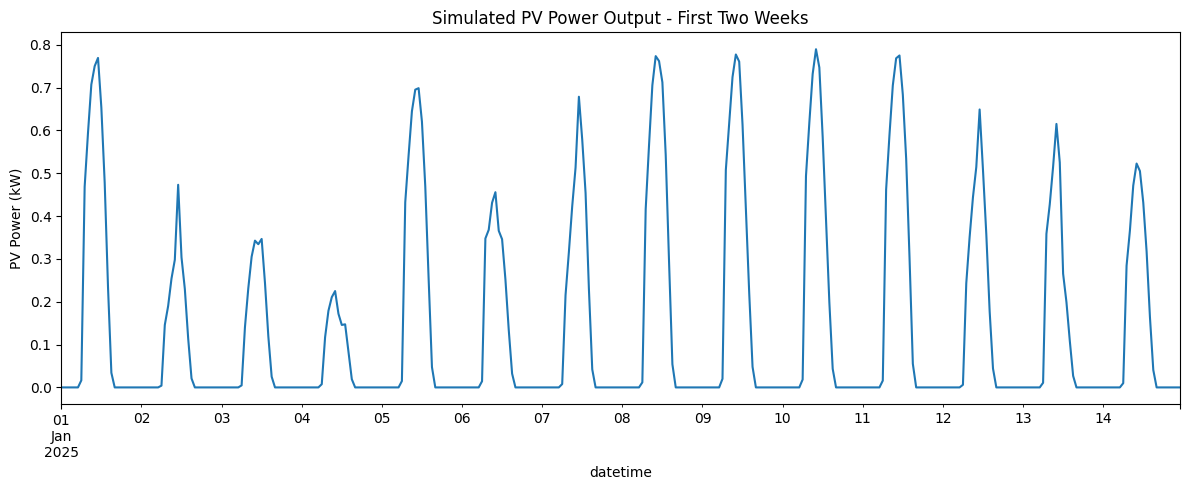

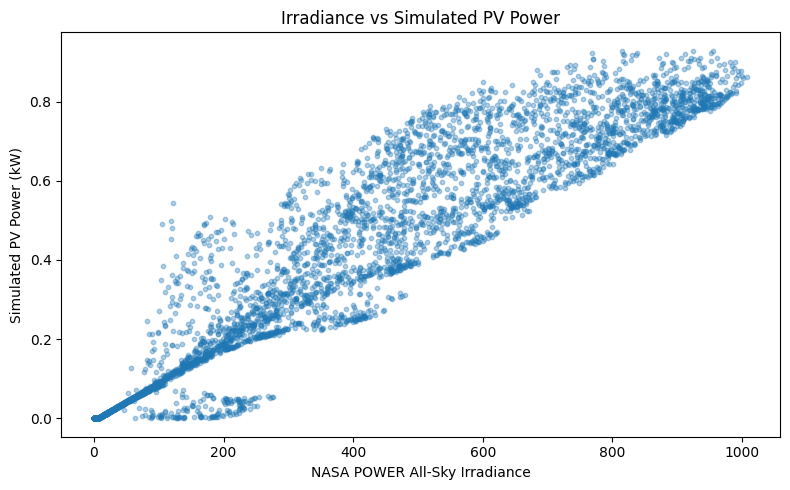

In [ ]:
# ==========================================================
# 6. EXPLORATORY PLOTS
# ==========================================================

def save_current_plot(filename):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


plt.figure(figsize=(12, 5))
pv_df["pv_power_kw"].iloc[:24*14].plot()
plt.ylabel("PV Power (kW)")
plt.title("Simulated PV Power Output - First Two Weeks")
save_current_plot("pv_power_timeseries.png")


plt.figure(figsize=(8, 5))
plt.scatter(pv_df["ALLSKY_SFC_SW_DWN"], pv_df["pv_power_kw"], alpha=0.35, s=10)
plt.xlabel("NASA POWER All-Sky Irradiance")
plt.ylabel("Simulated PV Power (kW)")
plt.title("Irradiance vs Simulated PV Power")
save_current_plot("irradiance_vs_pv_power.png")

## 7. Feature engineering

For tabular models, we use weather variables, PVLib simulation variables, time features, lag features, and rolling statistics.

For deep learning models, we build multivariate sequences.

In [ ]:
# ==========================================================
# 7. FEATURE ENGINEERING FOR TABULAR MODELS
# ==========================================================

TARGET = "pv_power_kw"


def add_time_features(df):
    data = df.copy()

    hour = data.index.hour
    dayofyear = data.index.dayofyear
    month = data.index.month

    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    data["doy_sin"] = np.sin(2 * np.pi * dayofyear / 365.25)
    data["doy_cos"] = np.cos(2 * np.pi * dayofyear / 365.25)

    data["month"] = month
    data["is_daylight"] = (data["ALLSKY_SFC_SW_DWN"] > 0).astype(int)

    return data


def build_feature_matrix(df):
    data = add_time_features(df)

    for lag in [1, 2, 3, 24, 48, 168]:
        data[f"pv_lag_{lag}"] = data[TARGET].shift(lag)

    for window in [3, 24, 48, 168]:
        data[f"pv_roll_mean_{window}"] = data[TARGET].shift(1).rolling(window).mean()
        data[f"pv_roll_std_{window}"] = data[TARGET].shift(1).rolling(window).std()

    feature_cols = [
        "ALLSKY_SFC_SW_DWN",
        "T2M",
        "WS10M",
        "QV2M",
        "PRECTOTCORR",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "month",
        "is_daylight",
    ]

    feature_cols += [c for c in data.columns if c.startswith("pv_lag_")]
    feature_cols += [c for c in data.columns if c.startswith("pv_roll_")]

    available_features = [c for c in feature_cols if c in data.columns]

    data = data.dropna(subset=available_features + [TARGET])

    X = data[available_features]
    y = data[TARGET]

    return X, y, data


def chronological_split(X, y, test_size=0.2):
    split_index = int(len(X) * (1 - test_size))

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    return X_train, X_test, y_train, y_test


X, y, modeling_df = build_feature_matrix(pv_df)

X_train, X_test, y_train, y_test = chronological_split(X, y, test_size=0.2)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\ny_test full summary:")
print(y_test.describe())

print("\nDaylight samples in y_test:", (y_test > 0.01).sum(), "out of", len(y_test))

X_train.head()

X_train: (6873, 25)
X_test : (1719, 25)
y_train: (6873,)
y_test : (1719,)

y_test full summary:
count    1719.000000
mean        0.161172
std         0.249853
min         0.000000
25%         0.000000
50%         0.000000
75%         0.304100
max         0.848334
Name: pv_power_kw, dtype: float64

Daylight samples in y_test: 704 out of 1719


,ALLSKY_SFC_SW_DWN,T2M,WS10M,QV2M,PRECTOTCORR,hour_sin,hour_cos,doy_sin,doy_cos,month,...,pv_lag_48,pv_lag_168,pv_roll_mean_3,pv_roll_std_3,pv_roll_mean_24,pv_roll_std_24,pv_roll_mean_48,pv_roll_std_48,pv_roll_mean_168,pv_roll_std_168
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00+00:00,0.0,16.45,8.73,9.13,0.15,0.000000,1.000000,0.137185,0.990545,1,...,0.0,0.0,0.0,0.0,0.144025,0.22313,0.129218,0.19716,0.123539,0.203878
2025-01-08 01:00:00+00:00,0.0,16.33,8.39,9.13,0.60,0.258819,0.965926,0.137185,0.990545,1,...,0.0,0.0,0.0,0.0,0.144025,0.22313,0.129218,0.19716,0.123539,0.203878
2025-01-08 02:00:00+00:00,0.0,16.28,8.64,9.10,1.28,0.500000,0.866025,0.137185,0.990545,1,...,0.0,0.0,0.0,0.0,0.144025,0.22313,0.129218,0.19716,0.123539,0.203878
2025-01-08 03:00:00+00:00,0.0,16.25,9.25,9.02,1.68,0.707107,0.707107,0.137185,0.990545,1,...,0.0,0.0,0.0,0.0,0.144025,0.22313,0.129218,0.19716,0.123539,0.203878
2025-01-08 04:00:00+00:00,0.0,16.18,9.82,8.84,1.47,0.866025,0.500000,0.137185,0.990545,1,...,0.0,0.0,0.0,0.0,0.144025,0.22313,0.129218,0.19716,0.123539,0.203878


## 8. Evaluation and plotting helpers

In [ ]:
# ==========================================================
# 8. EVALUATION AND PLOTTING HELPERS
# ==========================================================

def evaluate_regression(y_true, y_pred, model_name):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print(f"MAE  : {mae:.6f} kW")
    print(f"RMSE : {rmse:.6f} kW")
    print(f"R2   : {r2:.6f}")

    return {
        "Model": model_name,
        "MAE_kW": mae,
        "RMSE_kW": rmse,
        "R2": r2,
    }


def persistence_baseline(y_test):
    y_pred = y_test.shift(1).dropna()
    y_true = y_test.iloc[1:]
    return y_true, y_pred


def plot_actual_vs_predicted(y_true, y_pred, model_name, filename_suffix=None):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    n = min(300, len(y_true))

    plt.figure(figsize=(12, 5))
    plt.plot(y_true[:n], label="Actual")
    plt.plot(y_pred[:n], label="Predicted")
    plt.xlabel("Time Step")
    plt.ylabel("PV Power (kW)")
    plt.title(f"Actual vs Predicted PV Power - {model_name}")
    plt.legend()

    if filename_suffix is None:
        filename_suffix = model_name.lower().replace(" ", "_").replace("-", "_")

    save_current_plot(f"actual_vs_predicted_{filename_suffix}.png")


def daylight_evaluation(y_true, y_pred, model_name):
    y_true_series = pd.Series(np.asarray(y_true).reshape(-1))
    y_pred_series = pd.Series(np.asarray(y_pred).reshape(-1))

    daylight_mask = y_true_series > 0.01

    return evaluate_regression(
        y_true_series[daylight_mask],
        y_pred_series[daylight_mask],
        model_name + " - Daylight Only"
    )


def plot_daylight_only(y_true, y_pred, model_name):
    y_true_series = pd.Series(np.asarray(y_true).reshape(-1))
    y_pred_series = pd.Series(np.asarray(y_pred).reshape(-1))

    daylight_mask = y_true_series > 0.01

    plot_actual_vs_predicted(
        y_true_series[daylight_mask],
        y_pred_series[daylight_mask],
        model_name + " - Daylight Only",
        filename_suffix=model_name.lower().replace(" ", "_").replace("-", "_") + "_daylight_only"
    )

## 9. Baseline, Random Forest, and XGBoost


Persistence Baseline
MAE  : 0.053663 kW
RMSE : 0.103117 kW
R2   : 0.829059


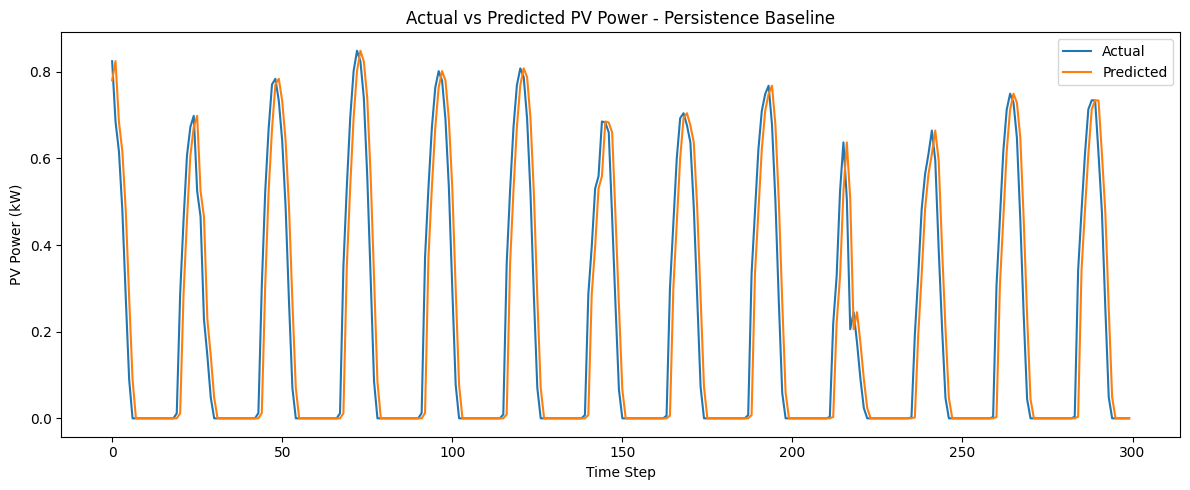


Persistence Baseline - Daylight Only
MAE  : 0.127264 kW
RMSE : 0.160617 kW
R2   : 0.576742


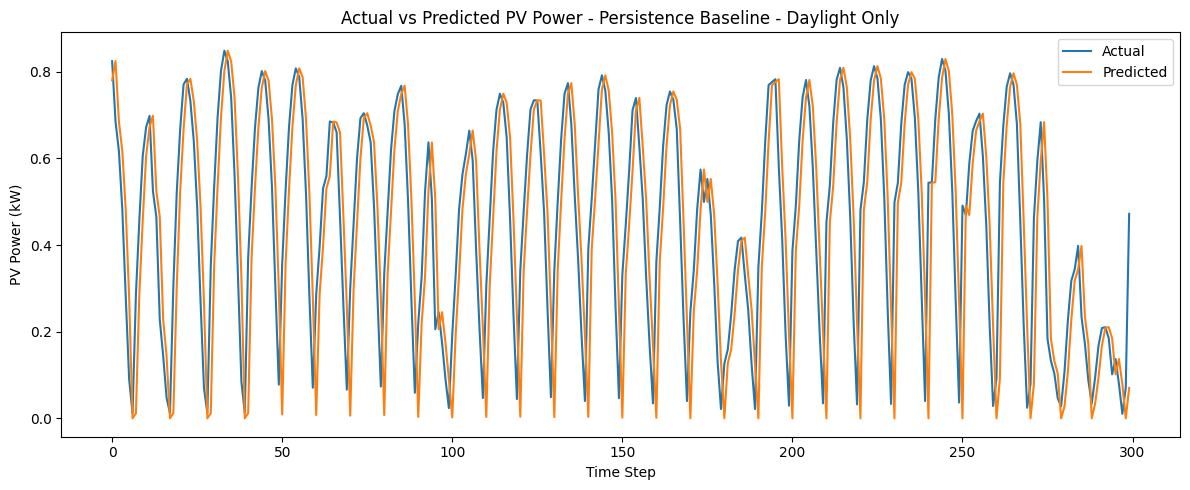


Random Forest
MAE  : 0.012743 kW
RMSE : 0.030874 kW
R2   : 0.984722


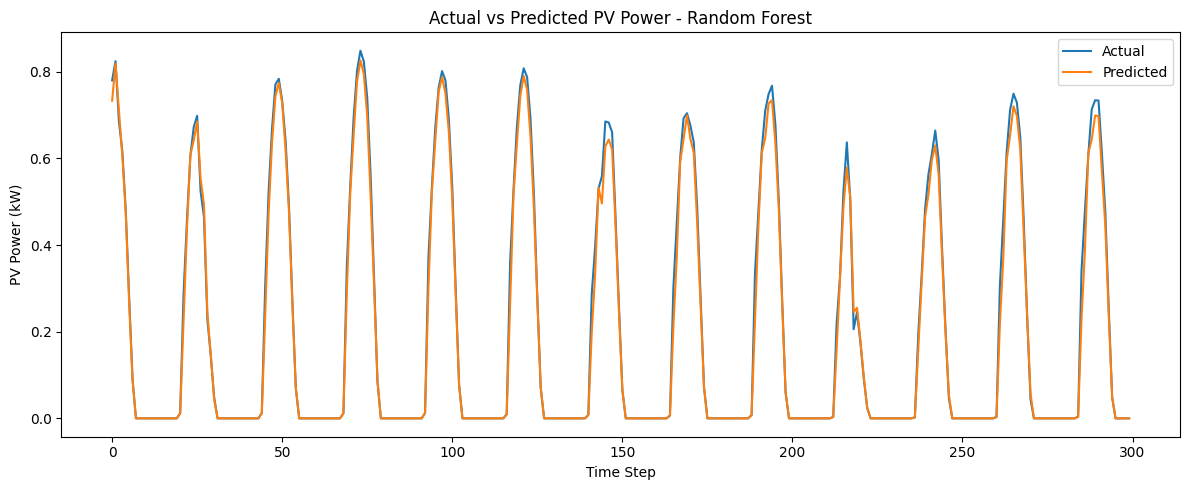


Random Forest - Daylight Only
MAE  : 0.031042 kW
RMSE : 0.048241 kW
R2   : 0.961897


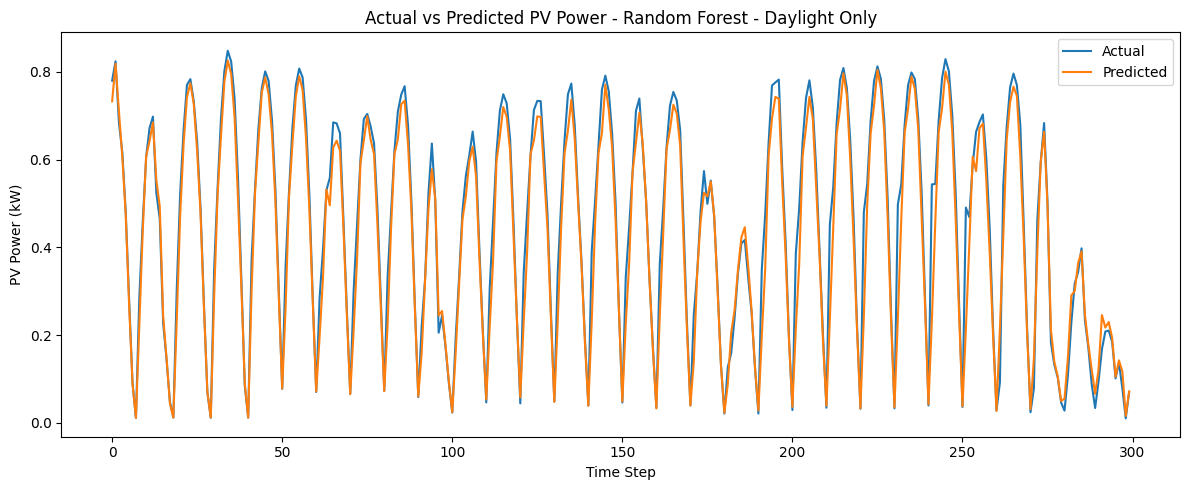

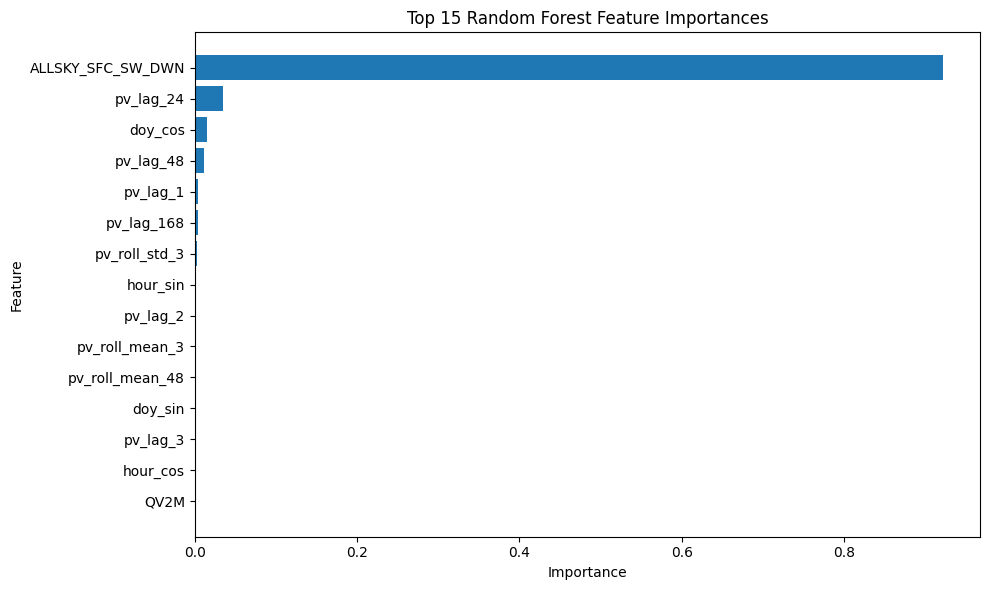


XGBoost
MAE  : 0.013249 kW
RMSE : 0.029804 kW
R2   : 0.985762


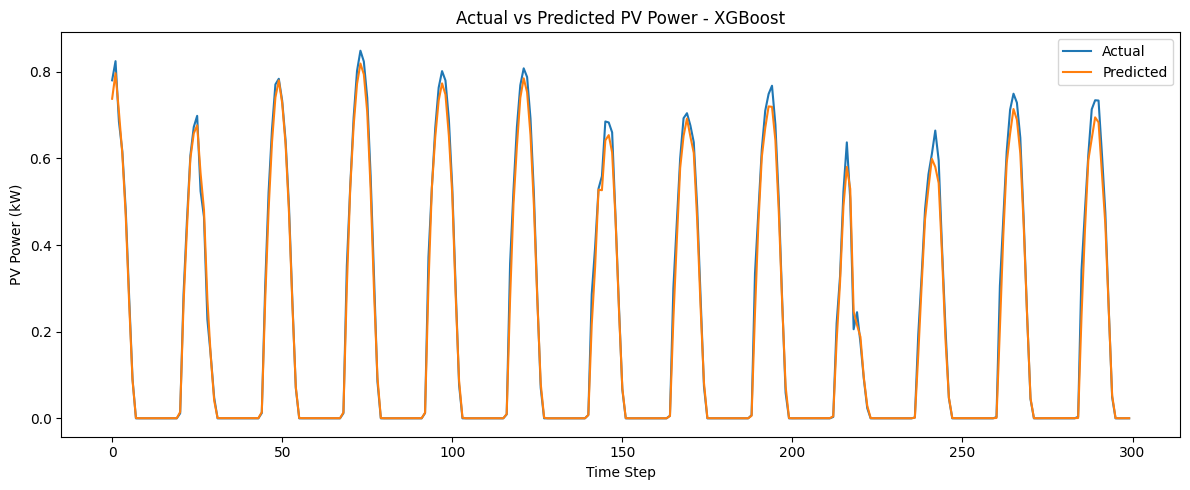


XGBoost - Daylight Only
MAE  : 0.031658 kW
RMSE : 0.046562 kW
R2   : 0.964504


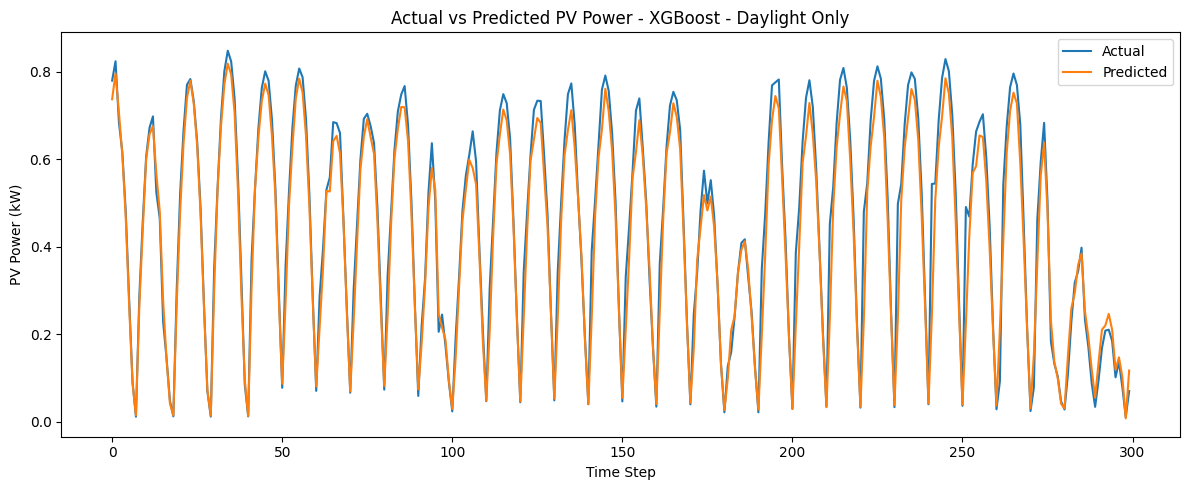

In [ ]:
# ==========================================================
# 9. PERSISTENCE, RANDOM FOREST, XGBOOST
# ==========================================================

results_full = []
results_daylight = []

# --------------------------
# Persistence Baseline
# --------------------------

y_true_base, y_pred_base = persistence_baseline(y_test)

results_full.append(
    evaluate_regression(y_true_base, y_pred_base, "Persistence Baseline")
)

plot_actual_vs_predicted(
    y_true_base,
    y_pred_base,
    "Persistence Baseline"
)

results_daylight.append(
    daylight_evaluation(y_true_base, y_pred_base, "Persistence Baseline")
)

plot_daylight_only(
    y_true_base,
    y_pred_base,
    "Persistence Baseline"
)

# --------------------------
# Random Forest
# --------------------------

rf_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results_full.append(
    evaluate_regression(y_test, rf_pred, "Random Forest")
)

plot_actual_vs_predicted(
    y_test,
    rf_pred,
    "Random Forest"
)

results_daylight.append(
    daylight_evaluation(y_test, rf_pred, "Random Forest")
)

plot_daylight_only(
    y_test,
    rf_pred,
    "Random Forest"
)

# Feature importance

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

top_importance = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
save_current_plot("feature_importance_random_forest.png")

feature_importance_df

# --------------------------
# XGBoost
# --------------------------

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

results_full.append(
    evaluate_regression(y_test, xgb_pred, "XGBoost")
)

plot_actual_vs_predicted(
    y_test,
    xgb_pred,
    "XGBoost"
)

results_daylight.append(
    daylight_evaluation(y_test, xgb_pred, "XGBoost")
)

plot_daylight_only(
    y_test,
    xgb_pred,
    "XGBoost"
)

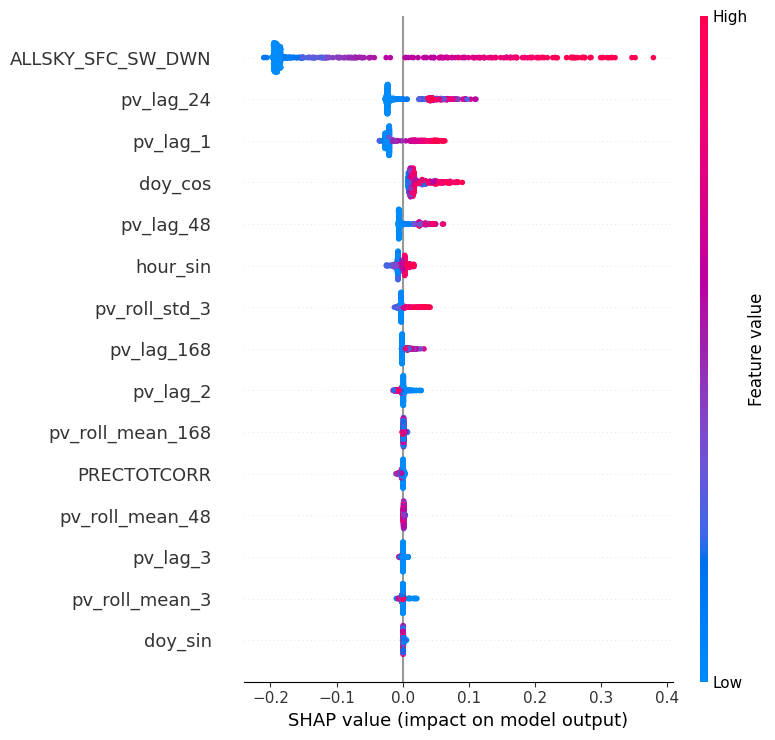

In [ ]:
# ==========================================================
# 10. SHAP EXPLAINABILITY FOR XGBOOST
# ==========================================================

try:
    import shap

    shap_sample = X_test.sample(min(500, len(X_test)), random_state=42)

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        show=False,
        max_display=15
    )

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shap_summary_xgboost.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as exc:
    print(f"SHAP plot skipped. Reason: {exc}")

## 10. SHAP explainability for XGBoost

SHAP helps explain which variables drive the XGBoost predictions. This may take a little time.

In [ ]:
# ==========================================================
# 11. DEEP LEARNING SEQUENCE PREPARATION
# ==========================================================

SEQUENCE_LENGTH = 24
EPOCHS = 60
BATCH_SIZE = 32


def create_sequences(df, sequence_length=24):
    data = add_time_features(df).copy()

    input_features = [
        "ALLSKY_SFC_SW_DWN",
        "T2M",
        "WS10M",
        "QV2M",
        "PRECTOTCORR",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "month",
        TARGET,
    ]

    input_features = [col for col in input_features if col in data.columns]

    data = data.dropna(subset=input_features + [TARGET])

    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    scaled_X = feature_scaler.fit_transform(data[input_features])
    scaled_y = target_scaler.fit_transform(data[[TARGET]])

    X_seq = []
    y_seq = []
    timestamps = []

    for i in range(sequence_length, len(data)):
        X_seq.append(scaled_X[i-sequence_length:i])
        y_seq.append(scaled_y[i])
        timestamps.append(data.index[i])

    return (
        np.array(X_seq),
        np.array(y_seq),
        np.array(timestamps),
        target_scaler,
        data,
    )


def chronological_sequence_split(X, y, timestamps, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))

    return (
        X[:split_idx],
        X[split_idx:],
        y[:split_idx],
        y[split_idx:],
        timestamps[:split_idx],
        timestamps[split_idx:],
    )


X_seq, y_seq, timestamps, target_scaler, sequence_df = create_sequences(
    pv_df,
    sequence_length=SEQUENCE_LENGTH
)

(
    X_train_seq,
    X_test_seq,
    y_train_seq,
    y_test_seq,
    train_timestamps,
    test_timestamps,
) = chronological_sequence_split(
    X_seq,
    y_seq,
    timestamps,
    test_size=0.2
)

n_features = X_seq.shape[2]

y_test_inv = target_scaler.inverse_transform(y_test_seq).reshape(-1)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("y_test_seq :", y_test_seq.shape)
print("y_test_inv summary:")
print(pd.Series(y_test_inv).describe())
print("Daylight samples in sequence test:", (y_test_inv > 0.01).sum(), "out of", len(y_test_inv))

X_train_seq: (6988, 24, 11)
X_test_seq : (1748, 24, 11)
y_train_seq: (6988, 1)
y_test_seq : (1748, 1)
y_test_inv summary:
count    1748.000000
mean        0.162444
std         0.250871
min         0.000000
25%         0.000000
50%         0.000000
75%         0.309531
max         0.848334
dtype: float64
Daylight samples in sequence test: 719 out of 1748


## 11. Deep learning sequence preparation

The models use the previous 24 hourly steps to predict the next simulated PV output value.

In [ ]:
# ==========================================================
# 12. DEEP LEARNING MODEL DEFINITIONS
# ==========================================================

def build_lstm(sequence_length, n_features):
   model = Sequential([
       LSTM(64, input_shape=(sequence_length, n_features), return_sequences=False),
       Dropout(0.2),
       Dense(32, activation="relu"),
       Dense(1),
   ])

   model.compile(
       optimizer=Adam(learning_rate=0.001),
       loss="mse"
   )

   return model





def build_cnn(sequence_length, n_features):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", input_shape=(sequence_length, n_features)),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model


def build_cnn_lstm(sequence_length, n_features):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", input_shape=(sequence_length, n_features)),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model
# def build_cnn_lstm(sequence_length, n_features):
#     model = Sequential([
#         Conv1D(
#             filters=32,
#             kernel_size=3,
#             activation="relu",
#             padding="same",
#             input_shape=(sequence_length, n_features)
#         ),
#         Dropout(0.2),

#         Conv1D(
#             filters=64,
#             kernel_size=3,
#             activation="relu",
#             padding="same"
#         ),
#         Dropout(0.2),

#         LSTM(64, return_sequences=False),

#         Dense(64, activation="relu"),
#         Dense(32, activation="relu"),
#         Dense(1),
#     ])

#     model.compile(
#         optimizer=Adam(learning_rate=0.0005),
#         loss="mse"
#     )

#     return model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
)

## 12. Deep learning model definitions


Training LSTM...
Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0164 - val_loss: 0.0055
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0044 - val_loss: 0.0034
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0037 - val_loss: 0.0034
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0033 - val_loss: 0.0031
Epoch 6/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 7/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 8/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0025 - val_loss: 0.0029
Epoch 9/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 10/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0022 - val_loss: 0.0027
Epoch 11/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 12/60
186/186 ━━━

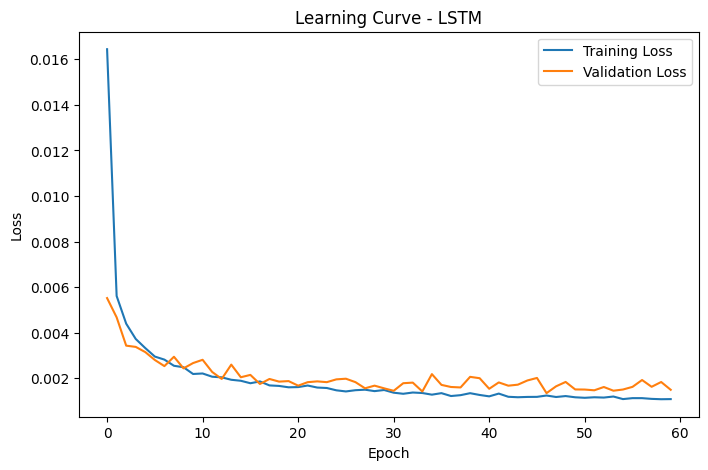


LSTM
MAE  : 0.027891 kW
RMSE : 0.060013 kW
R2   : 0.942742


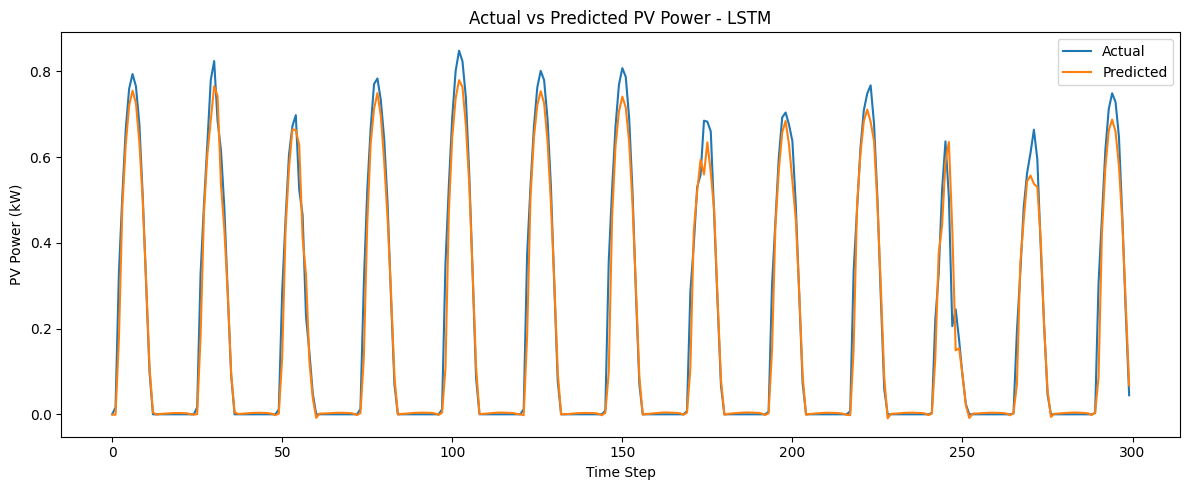


LSTM - Daylight Only
MAE  : 0.063007 kW
RMSE : 0.093397 kW
R2   : 0.857670


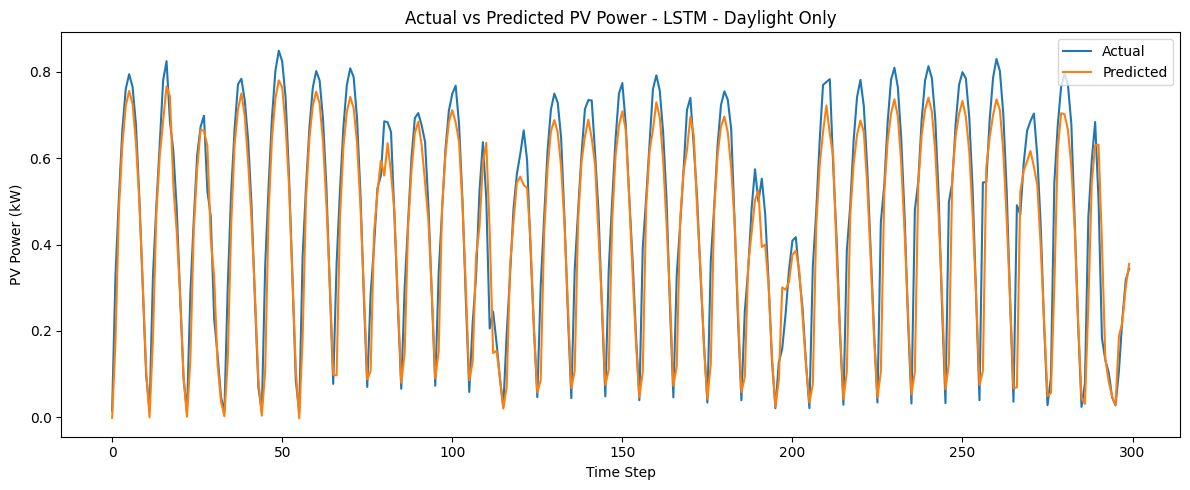


Training CNN...
Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0158 - val_loss: 0.0096
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0077 - val_loss: 0.0079
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0071 - val_loss: 0.0083
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0064 - val_loss: 0.0079
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0058 - val_loss: 0.0073
Epoch 6/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0056 - val_loss: 0.0062
Epoch 7/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0055 - val_loss: 0.0067
Epoch 8/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0053 - val_loss: 0.0071
Epoch 9/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0053 - val_loss: 0.0062
Epoch 10/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0053 - val_loss: 0.0062
Epoch 11/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0049 - val_loss: 0.0065
Epoch 12/60
186/186 ━━━━━━━━━━━━━

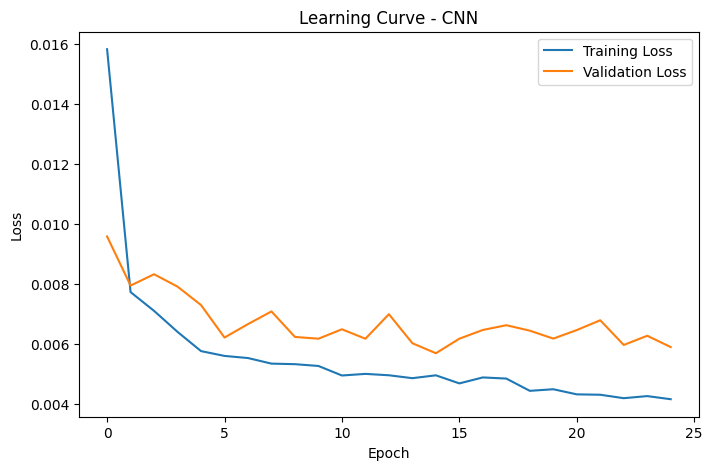


CNN
MAE  : 0.072934 kW
RMSE : 0.107744 kW
R2   : 0.815442


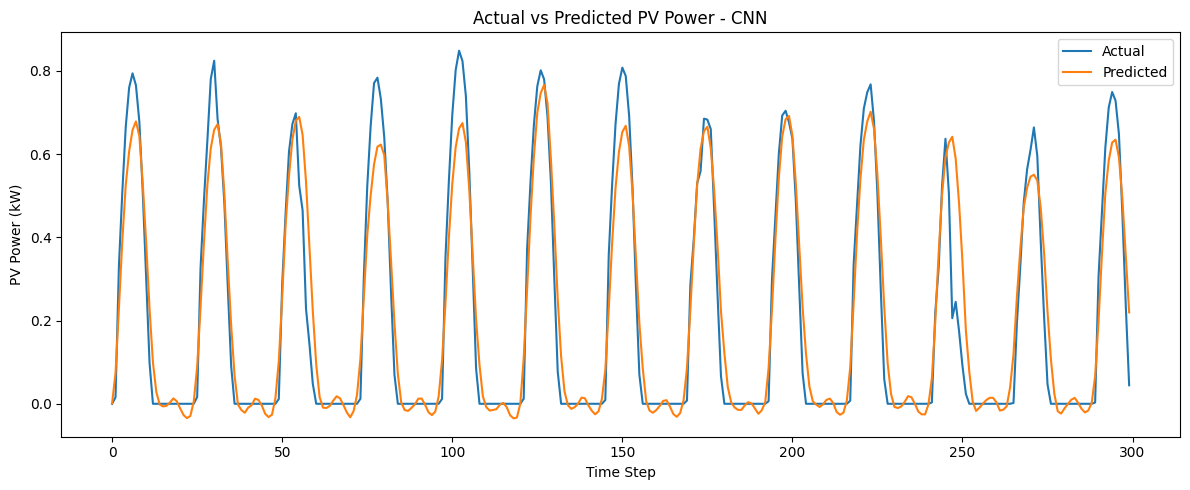


CNN - Daylight Only
MAE  : 0.135657 kW
RMSE : 0.158308 kW
R2   : 0.591083


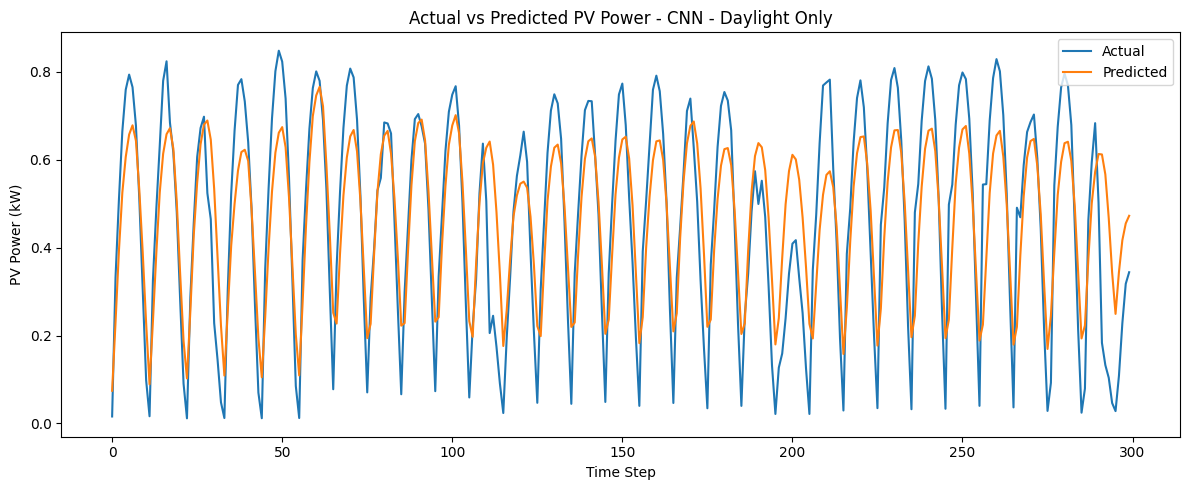


Training CNN-LSTM...
Epoch 1/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0191 - val_loss: 0.0059
Epoch 2/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0052 - val_loss: 0.0057
Epoch 3/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 4/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 5/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0030 - val_loss: 0.0027
Epoch 6/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 7/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 8/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 9/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 10/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 11/60
186/186 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 12/60
186/186

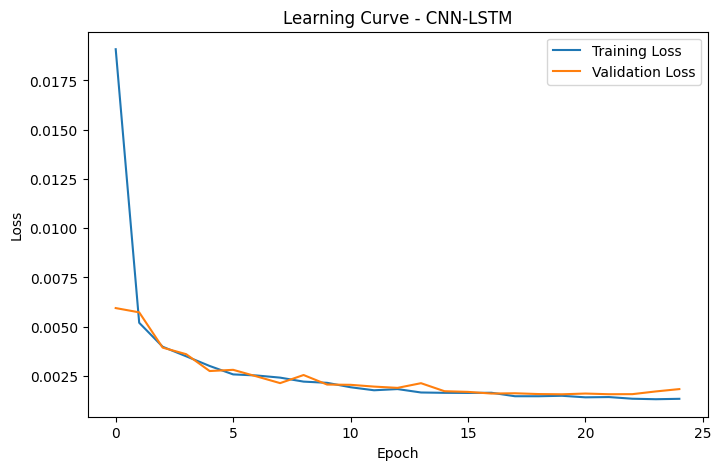


CNN-LSTM
MAE  : 0.061868 kW
RMSE : 0.089180 kW
R2   : 0.873560


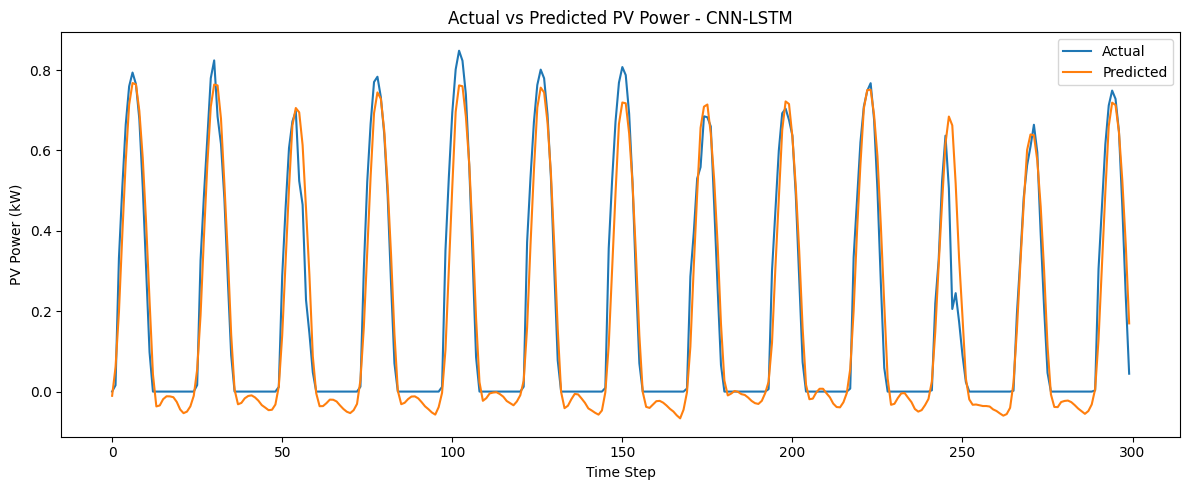


CNN-LSTM - Daylight Only
MAE  : 0.107425 kW
RMSE : 0.132517 kW
R2   : 0.713466


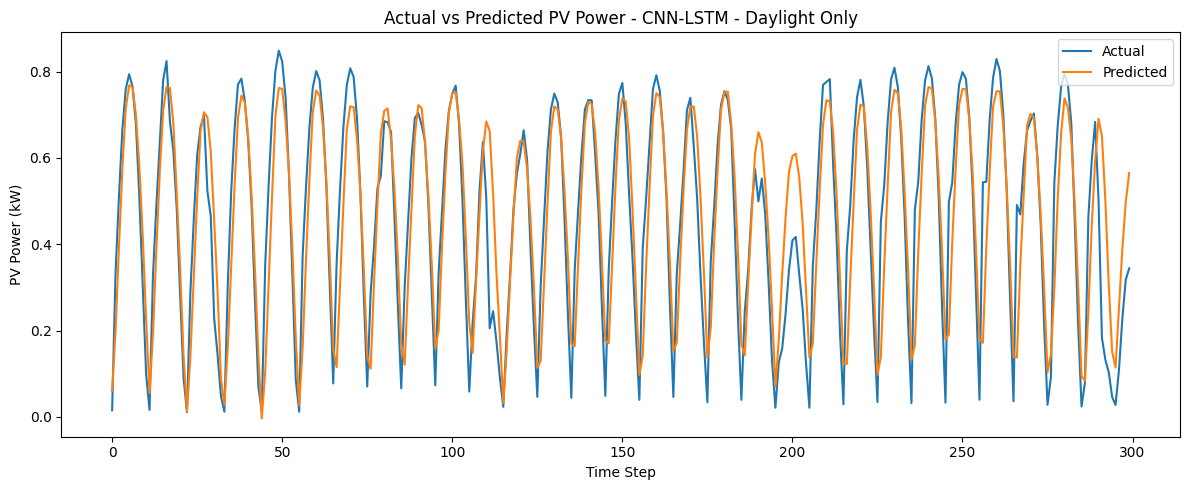

In [ ]:
# ==========================================================
# 13. TRAIN LSTM, CNN, CNN-LSTM
# ==========================================================

dl_models = {
    "LSTM": build_lstm(SEQUENCE_LENGTH, n_features),
    "CNN": build_cnn(SEQUENCE_LENGTH, n_features),
    "CNN-LSTM": build_cnn_lstm(SEQUENCE_LENGTH, n_features),
}

dl_histories = {}
def plot_learning_curve(history, model_name):

    plt.figure(figsize=(8,5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Curve - {model_name}")

    plt.legend()

    plt.show()
for model_name, model in dl_models.items():
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    print(f"\nTraining {model_name}...")

    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1,
    )

    dl_histories[model_name] = history
    plot_learning_curve(
    history,
    model_name
)
    pred_scaled = model.predict(X_test_seq, verbose=0)
    pred = target_scaler.inverse_transform(pred_scaled).reshape(-1)

    results_full.append(
        evaluate_regression(y_test_inv, pred, model_name)
    )

    plot_actual_vs_predicted(
        y_test_inv,
        pred,
        model_name
    )

    results_daylight.append(
        daylight_evaluation(y_test_inv, pred, model_name)
    )

    plot_daylight_only(
        y_test_inv,
        pred,
        model_name
    )

## 13. Train LSTM, CNN, and CNN-LSTM

If training is slow, reduce `EPOCHS` to 20 first. For final GitHub results, keep 50–60 epochs with early stopping.

In [ ]:
# ==========================================================
# 14. FINAL MODEL COMPARISON
# ==========================================================

results_full_df = pd.DataFrame(results_full).sort_values("RMSE_kW")
results_daylight_df = pd.DataFrame(results_daylight).sort_values("RMSE_kW")

results_full_df.to_csv(RESULTS_DIR / "model_comparison_full_24h.csv", index=False)
results_daylight_df.to_csv(RESULTS_DIR / "model_comparison_daylight_only.csv", index=False)

print("Full 24-hour evaluation:")
display(results_full_df)

print("Daylight-only evaluation:")
display(results_daylight_df)

Full 24-hour evaluation:


,Model,MAE_kW,RMSE_kW,R2
2,XGBoost,0.013249,0.029804,0.985762
1,Random Forest,0.012743,0.030874,0.984722
3,LSTM,0.027891,0.060013,0.942742
5,CNN-LSTM,0.061868,0.089180,0.873560
0,Persistence Baseline,0.053663,0.103117,0.829059
4,CNN,0.072934,0.107744,0.815442


Daylight-only evaluation:


,Model,MAE_kW,RMSE_kW,R2
2,XGBoost - Daylight Only,0.031658,0.046562,0.964504
1,Random Forest - Daylight Only,0.031042,0.048241,0.961897
3,LSTM - Daylight Only,0.063007,0.093397,0.857670
5,CNN-LSTM - Daylight Only,0.107425,0.132517,0.713466
4,CNN - Daylight Only,0.135657,0.158308,0.591083
0,Persistence Baseline - Daylight Only,0.127264,0.160617,0.576742


## 14. Final model comparison

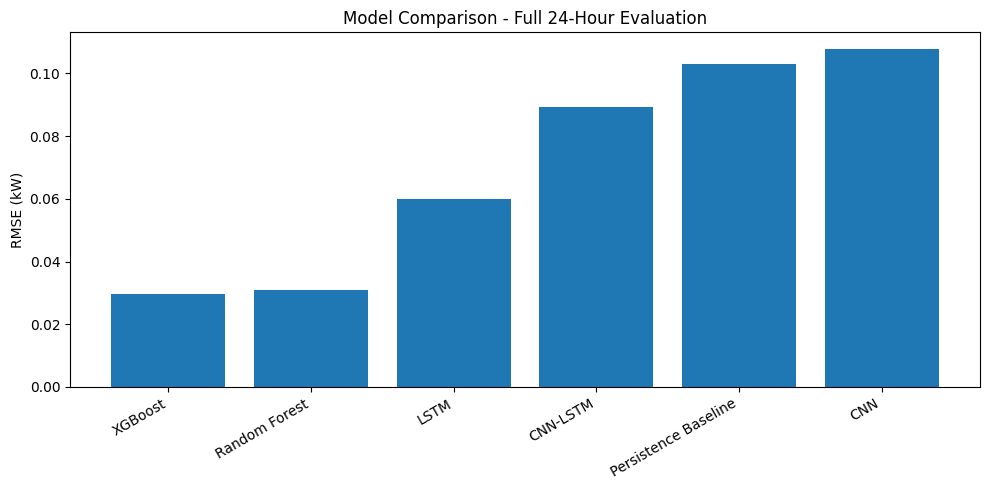

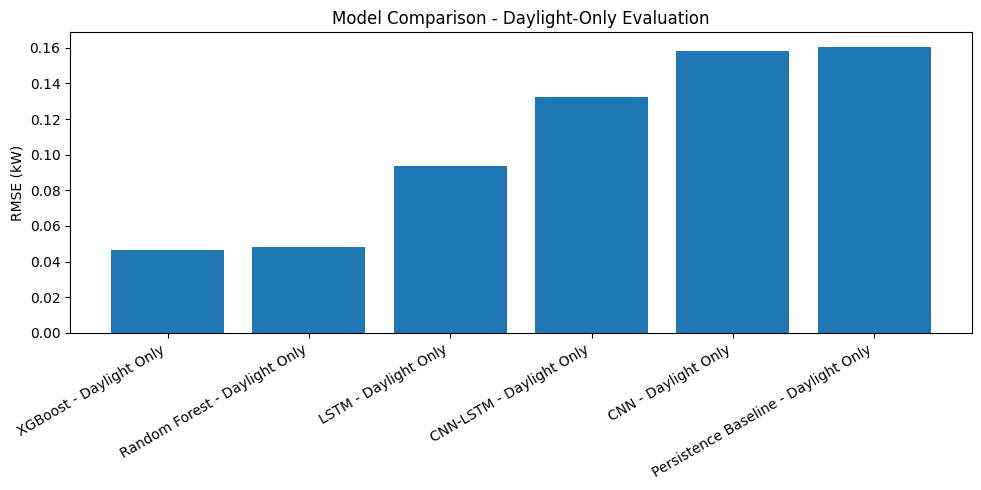

In [ ]:
# ==========================================================
# 15. PLOT MODEL COMPARISON
# ==========================================================

plt.figure(figsize=(10, 5))
sorted_df = results_full_df.sort_values("RMSE_kW")
plt.bar(sorted_df["Model"], sorted_df["RMSE_kW"])
plt.ylabel("RMSE (kW)")
plt.title("Model Comparison - Full 24-Hour Evaluation")
plt.xticks(rotation=30, ha="right")
save_current_plot("model_comparison_rmse_full_24h.png")


plt.figure(figsize=(10, 5))
sorted_df = results_daylight_df.sort_values("RMSE_kW")
plt.bar(sorted_df["Model"], sorted_df["RMSE_kW"])
plt.ylabel("RMSE (kW)")
plt.title("Model Comparison - Daylight-Only Evaluation")
plt.xticks(rotation=30, ha="right")
save_current_plot("model_comparison_rmse_daylight_only.png")

## 15. Discussion points for your GitHub README

Use these points in your README after you generate final results:

- PV output is simulated using PVLib and NASA POWER data, not measured from a real solar plant.
- Random Forest and XGBoost may perform very strongly because PV output is largely determined by irradiance, plane-of-array irradiance, temperature, and engineered lag features.
- Deep learning models are useful for sequence learning, but they are not always better than tree-based models on structured tabular energy data.
- The project demonstrates an engineering workflow: weather data → PV system simulation → forecasting → explainability.
- A limitation is that the target is simulated, so performance should not be interpreted as measured plant forecasting accuracy.

## 16. Download outputs from Colab

This creates a ZIP of the results folder, including figures and model comparison CSV.

In [ ]:
# ==========================================================
# 16. DOWNLOAD RESULTS
# ==========================================================

!zip -r solar_pv_results.zip results
files.download("solar_pv_results.zip")

  adding: results/ (stored 0%)
  adding: results/figures/ (stored 0%)
  adding: results/figures/pv_power_timeseries.png (deflated 7%)
  adding: results/figures/actual_vs_predicted_cnn_lstm_daylight_only.png (deflated 3%)
  adding: results/figures/actual_vs_predicted_persistence_baseline_daylight_only.png (deflated 3%)
  adding: results/figures/actual_vs_predicted_lstm.png (deflated 5%)
  adding: results/figures/model_comparison_rmse_daylight_only.png (deflated 18%)
  adding: results/figures/actual_vs_predicted_lstm_daylight_only.png (deflated 3%)
  adding: results/figures/actual_vs_predicted_cnn.png (deflated 5%)
  adding: results/figures/irradiance_vs_pv_power.png (deflated 4%)
  adding: results/figures/actual_vs_predicted_random_forest_daylight_only.png (deflated 3%)
  adding: results/figures/actual_vs_predicted_xgboost_daylight_only.png (deflated 3%)
  adding: results/figures/actual_vs_predicted_cnn_lstm.png (deflated 5%)
  adding: results/figures/actual_vs_predicted_xgboost.png (de

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>